https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/SoftRankWsdm08Submitted.pdf

In [1]:
import torch
import math
import seaborn as sns

In [2]:
def gaussian_cdf(value, loc, scale):
    return 0.5 * (1 + torch.erf((value - loc) * scale.reciprocal() / math.sqrt(2)))

In [3]:
def gaussian_survival_function(value, loc, scale):
    return 1 - gaussian_cdf(value, loc, scale)

In [ ]:
# equation (10) in the paper https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/SoftRankWsdm08Submitted.pdf
def expected_ranks(predicted_potential, predicted_scale=None):
    delta = predicted_potential.view(-1, 1) - predicted_potential.view(1, -1)
    if predicted_scale is None:
        scale = torch.ones(1)
    else:
        assert predicted_scale.size() == predicted_potential.size()
        scale = predicted_scale.view(-1, 1) + predicted_scale.view(1, -1)

    # Pr[rank(i) > rank(j)] (equation 9)
    pij = gaussian_survival_function(torch.zeros(1), delta, scale)
    # Equation 10
    return (1 - pij).sum(dim=1)


def soft_spearman(pred_scores, target_rank):
    soft_ranks = expected_ranks(pred_scores)
    assert soft_ranks.size(0) == target_rank.size(0)
    n = target_rank.size(0)
    target_rank = target_rank.view(soft_ranks.size())
    d = soft_ranks - target_rank
    return 1 - 6 * (d * d).sum() / (n * (n * n - 1))

In [5]:
def fit(params, criterion):
    opt = torch.optim.Adam([params], lr=0.01)
    for i in range(1000):
        opt.zero_grad()
        loss = criterion(params)
        loss.backward()
        opt.step()
        if i % 100 == 0:
            print(loss.item())
    return params

In [6]:
potential = torch.randn(6, requires_grad=True)
potential

tensor([-0.0221,  0.6781,  1.2567,  0.2015,  0.9536,  0.5259],
       requires_grad=True)

In [7]:
target_rank = torch.arange(6).float()
target_rank

tensor([0., 1., 2., 3., 4., 5.])

Text(0.5, 1.0, 'Initial potential vs target rank')

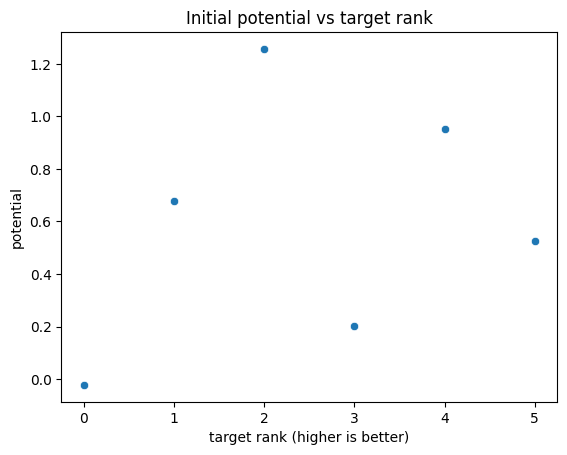

In [8]:
ax = sns.scatterplot(x=target_rank.numpy(), y=potential.detach().numpy())
ax.set_xlabel("target rank (higher is better)")
ax.set_ylabel("potential")
ax.set_title("Initial potential vs target rank")

In [9]:
fit(potential, lambda scores: -soft_spearman(scores, target_rank))

-0.16886776685714722
-0.8318668603897095
-0.912986159324646
-0.931823194026947
-0.9398475289344788
-0.9442369937896729
-0.9469825625419617
-0.9488510489463806
-0.9501987099647522
-0.9512130618095398


tensor([ 2.1503,  1.3394,  0.6057, -0.1005, -0.8260, -1.7078],
       requires_grad=True)

Text(0.5, 1.0, 'Fitted potential vs target rank')

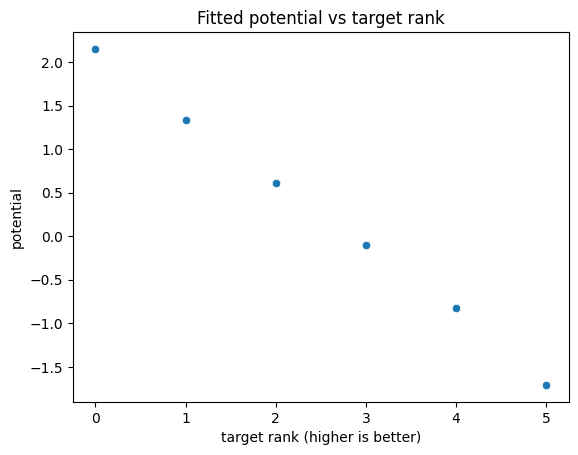

In [10]:
ax = sns.scatterplot(x=target_rank.numpy(), y=potential.detach().numpy())
ax.set_xlabel("target rank (higher is better)")
ax.set_ylabel("potential")
ax.set_title("Fitted potential vs target rank")